<a href="https://colab.research.google.com/github/salim928/Customer-sentiment-with-kMeans/blob/adamstemp/Customer_sentiment_with_kMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# settings to make numbers easier to read on displa
pd.options.display.float_format = '{:20.2f}'.format


# show all columns on output
pd.set_option('display.max_columns', 999)

# Data Exploration

In [2]:
df = pd.read_csv('/content/online_retail_II.csv')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [3]:
df.loc[:, 'InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [4]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
# checking for high level statistics of the numerical part of the data

df.describe()

,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00


In [7]:
df.describe(include='object')

<ipython-input-7-e9c15d751cf5>:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  df.describe(include='object')


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330


Upon a few statistical readings, it is clear some data is missing

In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


Checking these specific columns with empty data

In [9]:
df[df['Customer ID'].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


checking the negative quantity

In [10]:
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


##### In the data description there is something like C' indicating cancellations

In [11]:
# checking if the invoice is actually 6 digits and find ones with C

df['Invoice'] = df['Invoice'].astype('str')
df[df['Invoice'].str.match("^\\d{6}$") == True]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France


In [12]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [13]:
# checking if the invoice is actually 6 digits and find ones with C

df['Invoice'] = df['Invoice'].astype('str')
df[df['Invoice'].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.00,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.00,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.00,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.00,United Kingdom


In [14]:
# checking if c is the only digit
df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [15]:
df[df['Invoice'].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


Stock Code Must Have 5 Digit Numbers

In [16]:
df['StockCode'] = df['StockCode'].astype('str')
df[(df['StockCode'].str.match("^\\d{5}$") == False) & (df['StockCode'].str.match("^\\d{5}[a-zA-Z]+$") == False)]['StockCode'].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE',
       'DCGS0055', 'DCGS0074', 'DCGS0057', 'DCGS0073', 'DCGS0071',
       'DCGS0066P', 'DCGS0067', 'CRUK'], dtype=object)

Here we have to go through all these unique stock codes and see what they mean
```
# This is formatted as code
```



In [17]:
df[df['StockCode'].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062295,581219,DOT,DOTCOM POSTAGE,1,2011-12-08 09:28:00,1008.96,NaN,United Kingdom
1062715,581238,DOT,DOTCOM POSTAGE,1,2011-12-08 10:53:00,1683.75,NaN,United Kingdom
1064829,581439,DOT,DOTCOM POSTAGE,1,2011-12-08 16:30:00,938.59,NaN,United Kingdom
1066369,581492,DOT,DOTCOM POSTAGE,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom


In [18]:
df[df['StockCode'].str.contains("^POST")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.00,France
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.00,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.00,Belgium
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,12533.00,Germany
927,C489538,POST,POSTAGE,-1,2009-12-01 12:18:00,9.58,15796.00,United Kingdom
...,...,...,...,...,...,...,...,...
1066677,581494,POST,POSTAGE,2,2011-12-09 10:13:00,18.00,12518.00,Germany
1067191,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.00,Germany
1067228,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.00,Germany
1067229,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713.00,Germany


In [19]:
df[df['StockCode'].str.contains("^PADS")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,0.00,16705.00,United Kingdom
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,0.00,13583.00,United Kingdom
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,0.00,17350.00,United Kingdom
79794,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-03 11:58:00,0.00,13408.00,United Kingdom
90798,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-15 10:47:00,0.00,13408.00,United Kingdom
97716,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-21 12:03:00,0.00,15182.00,United Kingdom
101718,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-24 13:46:00,0.00,13765.00,United Kingdom
104480,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-26 13:26:00,0.00,14459.00,United Kingdom
123947,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-03-15 11:00:00,0.00,14857.00,United Kingdom
156809,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-04-12 16:30:00,0.00,12671.00,Germany


Data Cleaning

In [20]:
cleaned_df = df.copy()

In [21]:
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype('str')

# A mask is just a filter expression, here we have filtered out the invoices which do not match this pattern
mask = (
    cleaned_df['Invoice'].str.match("^\\d{6}$") == True
 )

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France


In [22]:
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype('str')

# A mask is just a filter expression, here we have filtered out the StockCodes which do not match this pattern
mask = (
    (cleaned_df['StockCode'].str.match("^\\d{5}$") == True) |
    (cleaned_df['StockCode'].str.match("^PADS$") == True) |
    (cleaned_df['StockCode'].str.match("^\\d{5}[a-zA-Z]+$") == True)
 )


# APPLY THE MASK TO CLEANED DF
cleaned_df = cleaned_df[mask]

cleaned_df

<ipython-input-22-37dec9778ecb>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['StockCode'] = cleaned_df['StockCode'].astype('str')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.00,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France


In [23]:
cleaned_df.loc[:, 'InvoiceDate'] = pd.to_datetime(cleaned_df['InvoiceDate'])

In [24]:
cleaned_df.describe()

,Quantity,Price,Customer ID
count,1043010.00,1043010.00,802711.00
mean,10.62,3.32,15338.07
std,135.47,4.73,1693.93
min,-9600.00,0.00,12346.00
25%,1.00,1.25,13988.00
50%,3.00,2.10,15276.00
75%,10.00,4.13,16809.00
max,80995.00,1157.15,18287.00


In [25]:
cleaned_df.dropna(subset=['Customer ID'], inplace=True)

<ipython-input-25-1582879bfe74>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.dropna(subset=['Customer ID'], inplace=True)


In [26]:
cleaned_df.describe()

,Quantity,Price,Customer ID
count,802711.00,802711.00,802711.00
mean,13.34,2.93,15338.07
std,144.54,4.28,1693.93
min,1.00,0.00,12346.00
25%,2.00,1.25,13988.00
50%,5.00,1.95,15276.00
75%,12.00,3.75,16809.00
max,80995.00,649.50,18287.00


In [27]:
# looking at what the 0 prie mean

cleaned_df[cleaned_df['Price'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.00,16126.00,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.00,15658.00,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.00,14108.00,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.00,14108.00,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.00,15070.00,United Kingdom
...,...,...,...,...,...,...,...,...
979924,575579,22437,SET OF 9 BLACK SKULL BALLOONS,20,2011-11-10 11:49:00,0.00,13081.00,United Kingdom
979925,575579,22089,PAPER BUNTING VINTAGE PAISLEY,24,2011-11-10 11:49:00,0.00,13081.00,United Kingdom
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.00,15602.00,United Kingdom
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.00,12444.00,Norway


In [28]:
len(cleaned_df[cleaned_df['Price'] == 0])

62

In [29]:
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]

In [30]:
cleaned_df.describe()

,Quantity,Price,Customer ID
count,802649.00,802649.00,802649.00
mean,13.32,2.93,15338.15
std,143.87,4.28,1693.90
min,1.00,0.00,12346.00
25%,2.00,1.25,13988.00
50%,5.00,1.95,15276.00
75%,12.00,3.75,16809.00
max,80995.00,649.50,18287.00


In [31]:
# let's see the min value , there could be a hidden truth

cleaned_df['Price'].min()

0.001

checking the data lost during cleaning so far

In [32]:
len(df) - len(cleaned_df)

264722

In [33]:
len(cleaned_df) / len(df)

0.7519868911559336

Dropped 25% of data during cleaning

# Feature Engineering
The feature we need would be the efficiency(days of purchase), frequency(number of times of purchase), and the price(monetory amount spent)................


let's first check the blind total

In [34]:
# sum of monetory value

cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]

cleaned_df

<ipython-input-34-81d127213f2e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.00,France,10.20
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France,16.60


In [35]:
# aggregate or grouby customer ID

aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False)\
    .agg(
        MonetaryValue = ("SalesLineTotal", "sum"),
        Frequency = ("Invoice", "nunique"),
        LastInvoiceDate = ("InvoiceDate", "max")
    )

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,77352.96,3,2011-01-18 10:01:00
1,12347.00,5633.32,8,2011-12-07 15:52:00
2,12348.00,1658.40,5,2011-09-25 13:13:00
3,12349.00,3678.69,3,2011-11-21 09:51:00
4,12350.00,294.40,1,2011-02-02 16:01:00


In [36]:
max_invoice_date = aggregated_df['LastInvoiceDate'].max()

max_invoice_date

Timestamp('2011-12-09 12:50:00')

In [37]:
aggregated_df['Recency'] = (max_invoice_date - pd.to_datetime(aggregated_df['LastInvoiceDate'])).dt.days

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,77352.96,3,2011-01-18 10:01:00,325
1,12347.00,5633.32,8,2011-12-07 15:52:00,1
2,12348.00,1658.40,5,2011-09-25 13:13:00,74
3,12349.00,3678.69,3,2011-11-21 09:51:00,18
4,12350.00,294.40,1,2011-02-02 16:01:00,309


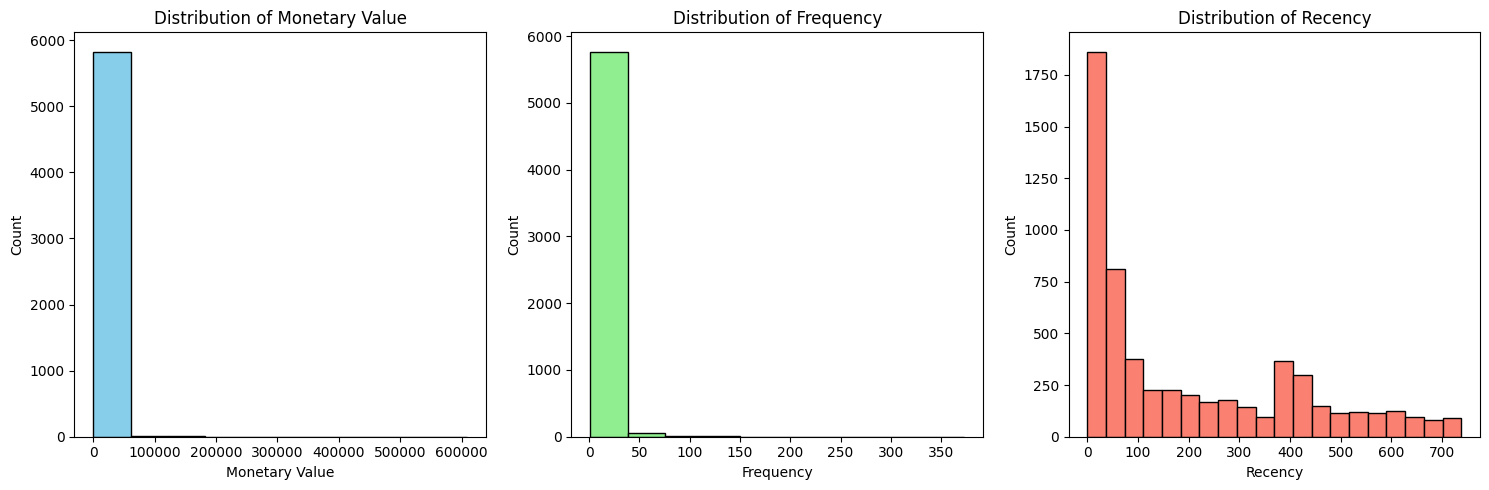

In [38]:
plt.figure(figsize=(15,5))


plt.subplot(1, 3, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Monetary Value')
plt.ylabel('Count')
plt.title('Distribution of Monetary Value')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title('Distribution of Frequency')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.xlabel('Recency')
plt.ylabel('Count')
plt.title('Distribution of Recency')

plt.tight_layout()
plt.show()

In [39]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=3, subplot_titles=("Distribution of Monetary Value", "Distribution of Frequency", "Distribution of Recency"))

fig.add_trace(go.Histogram(x=aggregated_df['MonetaryValue'], nbinsx=10, marker_color='skyblue', marker_line_color='black', name='Monetary Value'), row=1, col=1)
fig.add_trace(go.Histogram(x=aggregated_df['Frequency'], nbinsx=10, marker_color='lightgreen', marker_line_color='black', name='Frequency'), row=1, col=2)
fig.add_trace(go.Histogram(x=aggregated_df['Recency'], nbinsx=20, marker_color='salmon', marker_line_color='black', name='Recency'), row=1, col=3)

fig.update_xaxes(title_text="Monetary Value", row=1, col=1)
fig.update_xaxes(title_text="Frequency", row=1, col=2)
fig.update_xaxes(title_text="Recency", row=1, col=3)

fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=3)

fig.update_layout(height=500, width=1500, showlegend=False)
fig.show()

Looking for outliers, being rigorous

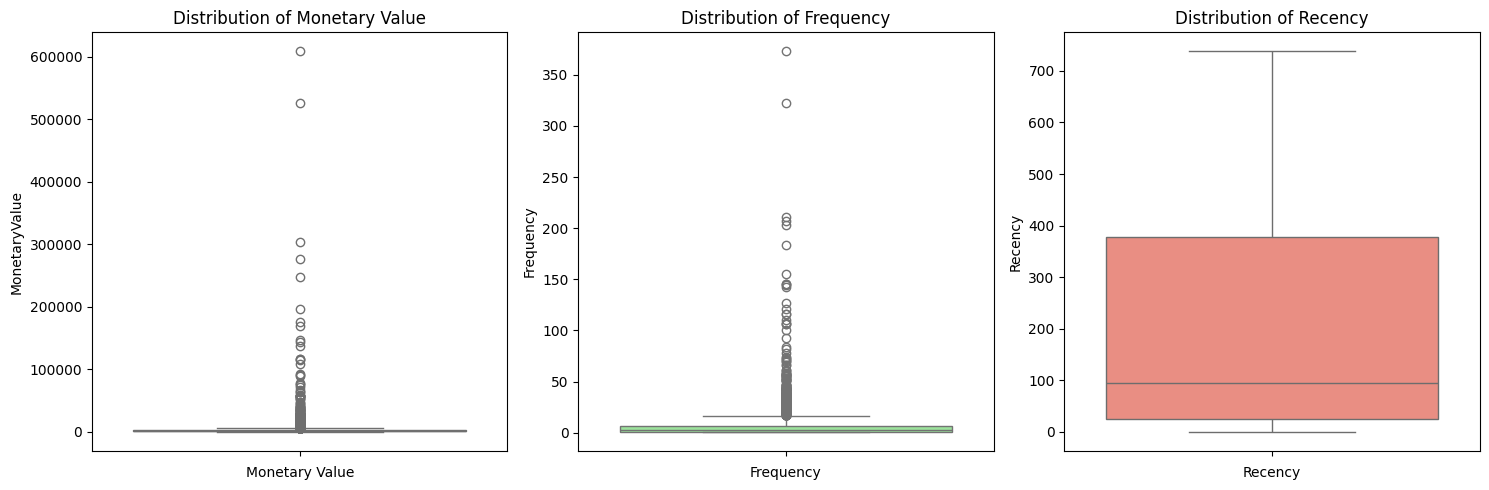

In [40]:
plt.figure(figsize=(15,5))


plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.xlabel('Monetary Value')
plt.title('Distribution of Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.xlabel('Frequency')
plt.title('Distribution of Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.xlabel('Recency')
plt.title('Distribution of Recency')

plt.tight_layout()
plt.show()

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=3, subplot_titles=("Distribution of Monetary Value", "Distribution of Frequency", "Distribution of Recency"))

fig.add_trace(go.Box(y=aggregated_df['MonetaryValue'], name='Monetary Value', marker_color='skyblue'), row=1, col=1)
fig.add_trace(go.Box(y=aggregated_df['Frequency'], name='Frequency', marker_color='lightgreen'), row=1, col=2)
fig.add_trace(go.Box(y=aggregated_df['Recency'], name='Recency', marker_color='salmon'), row=1, col=3)

fig.update_xaxes(title_text="Monetary Value", row=1, col=1)
fig.update_xaxes(title_text="Frequency", row=1, col=2)
fig.update_xaxes(title_text="Recency", row=1, col=3)


fig.update_layout(height=500, width=1500, showlegend=False)
fig.show()

Using the interquartile range method to separate the outlier

In [42]:
M_Q1 = aggregated_df['MonetaryValue'].quantile(0.25)
M_Q3 = aggregated_df['MonetaryValue'].quantile(0.75)
M_IQR = M_Q3 - M_Q1

# seperating outliers

monetary_outliers_df = aggregated_df[(aggregated_df['MonetaryValue'] > M_Q3 + 1.5 * M_IQR) | (aggregated_df['MonetaryValue'] < M_Q1 - 1.5 * M_IQR) ].copy()


monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,Recency
count,620.00,620.00,620.00,620.00
mean,15077.78,18260.64,25.98,50.98
std,1754.42,41750.24,31.13,102.87
min,12346.00,5217.44,1.00,0.00
25%,13573.00,6591.86,12.00,4.00
50%,14924.00,9131.81,18.00,16.00
75%,16607.50,14486.35,29.00,47.25
max,18260.00,608821.65,373.00,691.00


In [43]:
M_Q1 = aggregated_df['Frequency'].quantile(0.25)
M_Q3 = aggregated_df['Frequency'].quantile(0.75)
M_IQR = M_Q3 - M_Q1

# seperating outliers

frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > M_Q3 + 1.5 * M_IQR) | (aggregated_df['Frequency'] < M_Q1 - 1.5 * M_IQR) ].copy()


frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,Recency
count,424.00,424.00,424.00,424.00
mean,15373.75,21143.85,34.87,30.79
std,1777.62,49369.50,34.68,70.63
min,12415.00,1820.44,17.00,0.00
25%,13851.00,6368.09,20.00,2.75
50%,15306.00,9760.71,25.00,9.00
75%,16947.25,16691.30,35.00,24.00
max,18283.00,608821.65,373.00,575.00


In [44]:
non_outlier_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers_df.index))]

non_outlier_df.describe()

,Customer ID,MonetaryValue,Frequency,Recency
count,5167.00,5167.00,5167.00,5167.00
mean,15341.72,1133.52,3.69,218.90
std,1705.11,1128.97,3.19,211.12
min,12348.00,2.95,1.00,0.00
25%,13862.50,311.03,1.00,32.00
50%,15355.00,717.51,3.00,133.00
75%,16811.50,1579.13,5.00,392.00
max,18287.00,5202.97,16.00,738.00


In [45]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=3, subplot_titles=("Distribution of Monetary Value", "Distribution of Frequency", "Distribution of Recency"))

fig.add_trace(go.Box(y=non_outlier_df['MonetaryValue'], name='Monetary Value', marker_color='skyblue'), row=1, col=1)
fig.add_trace(go.Box(y=non_outlier_df['Frequency'], name='Frequency', marker_color='lightgreen'), row=1, col=2)
fig.add_trace(go.Box(y=non_outlier_df['Recency'], name='Recency', marker_color='salmon'), row=1, col=3)

fig.update_xaxes(title_text="Monetary Value", row=1, col=1)
fig.update_xaxes(title_text="Frequency", row=1, col=2)
fig.update_xaxes(title_text="Recency", row=1, col=3)


fig.update_layout(height=500, width=1500, showlegend=False)
fig.show()

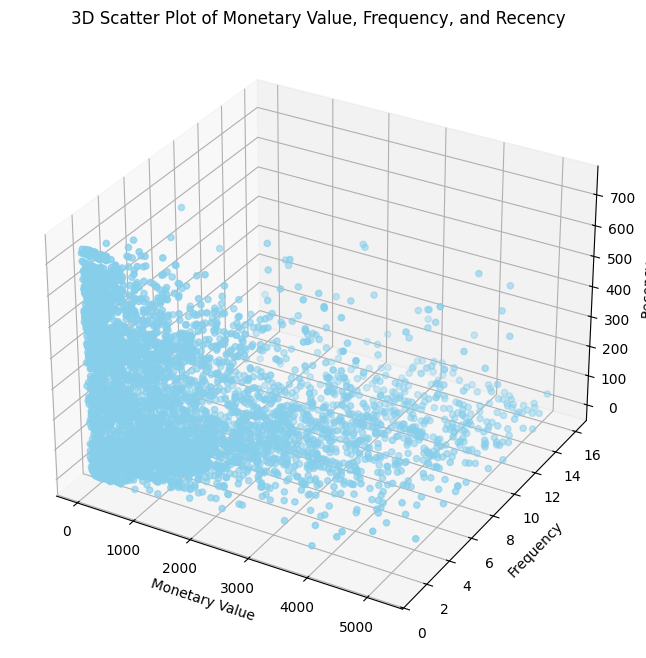

In [46]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(non_outlier_df['MonetaryValue'], non_outlier_df['Frequency'], non_outlier_df['Recency'], c='skyblue', marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Monetary Value, Frequency, and Recency')

plt.show()

In [47]:
import plotly.graph_objects as go

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=non_outlier_df['MonetaryValue'],
    y=non_outlier_df['Frequency'],
    z=non_outlier_df['Recency'],
    mode='markers',
    marker=dict(
        color='skyblue',
        size=5,  # You can adjust marker size
        symbol='circle'  # Equivalent to matplotlib's 'o'
    )
)])

# Update layout with labels and title
fig.update_layout(
    title='3D Scatter Plot of Monetary Value, Frequency, and Recency',
    scene=dict(
        xaxis_title='Monetary Value',
        yaxis_title='Frequency',
        zaxis_title='Recency'
    ),
    width=800,  # Matches figsize=(8,8) assuming ~100dpi
    height=800
)

# Show the plot
fig.show()

Using standard scaler to give equal priorities to each feature, by making their mean = 0 and their std = 1ensuring each feature contributes equally

In [48]:
scaler = StandardScaler()

scaled_df = scaler.fit_transform(non_outlier_df[['MonetaryValue', 'Frequency','Recency']])

scaled_df

array([[ 0.46495994,  0.41035762, -0.68639195],
       [ 2.25462817, -0.21575129, -0.95167175],
       [-0.74333563, -0.84186021,  0.42683577],
       ...,
       [-0.67016465, -0.84186021,  2.08957165],
       [ 0.10001748, -0.52880575,  1.21793803],
       [ 2.65706855,  1.03646654, -0.8379804 ]])

In [49]:
scaled_df = pd.DataFrame(scaled_df, index=non_outlier_df.index, columns=['MonetaryValue', 'Frequency','Recency'])

scaled_df

,MonetaryValue,Frequency,Recency
2,0.46,0.41,-0.69
3,2.25,-0.22,-0.95
4,-0.74,-0.84,0.43
5,-0.74,-0.84,0.73
6,0.53,1.66,-0.87
...,...,...,...
5846,-0.85,-0.53,-1.00
5848,-0.64,-0.84,1.00
5849,-0.67,-0.84,2.09
5850,0.10,-0.53,1.22


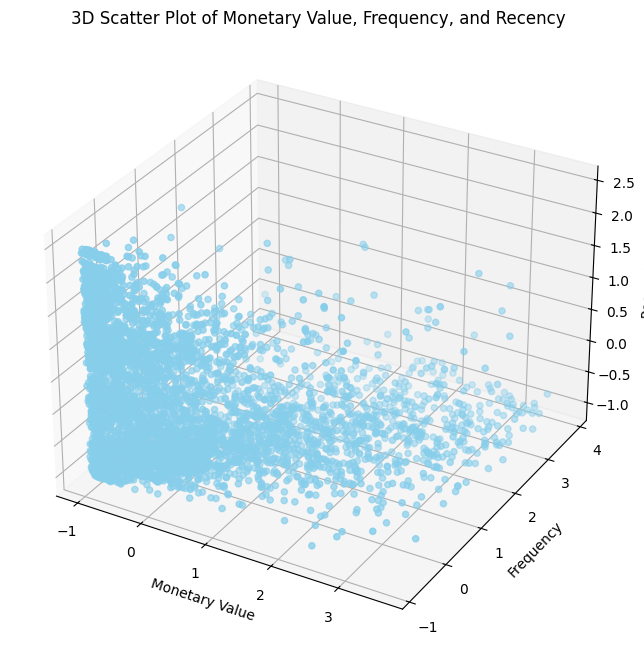

In [50]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(scaled_df['MonetaryValue'], scaled_df['Frequency'], scaled_df['Recency'], c='skyblue', marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Monetary Value, Frequency, and Recency')

plt.show()

In [51]:
import plotly.graph_objects as go

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=scaled_df['MonetaryValue'],
    y=scaled_df['Frequency'],
    z=scaled_df['Recency'],
    mode='markers',
    marker=dict(
        color='skyblue',
        size=5,  # You can adjust marker size
        symbol='circle'  # Equivalent to matplotlib's 'o'
    )
)])

# Update layout with labels and title
fig.update_layout(
    title='3D Scatter Plot of Monetary Value, Frequency, and Recency',
    scene=dict(
        xaxis_title='Monetary Value',
        yaxis_title='Frequency',
        zaxis_title='Recency'
    ),
    width=800,  # Matches figsize=(8,8) assuming ~100dpi
    height=800
)

# Show the plot
fig.show()

# KMean Clustering

In [52]:
from sklearn.metrics import silhouette_score

max_k = 12

inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(scaled_df)

    # Calculate and append the silhouette score using a different variable name (sil_score)
    sil_score = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(sil_score)

    # Average distance between clusters
    inertia.append(kmeans.inertia_)

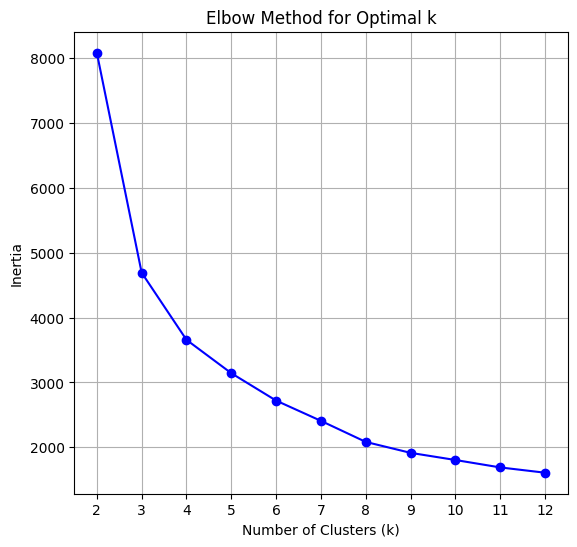

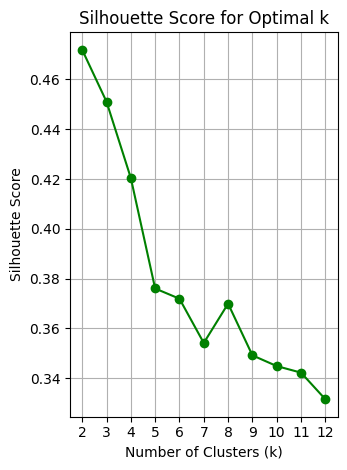

In [53]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='g')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [54]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Elbow Method for Optimal k", "Silhouette Score for Optimal k"))

fig.add_trace(
    go.Scatter(x=list(k_values), y=inertia, mode='lines+markers', name='Inertia', marker=dict(color='blue')), # Changed color='b' to color='blue'
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=list(k_values), y=silhouette_scores, mode='lines+markers', name='Silhouette Score', marker=dict(color='green')), # Changed color='g' to color='green'
    row=1, col=2
)

# Update layout
fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=1)
fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=2)
fig.update_yaxes(title_text="Inertia", row=1, col=1)
fig.update_yaxes(title_text="Silhouette Score", row=1, col=2)
fig.update_layout(height=500, width=1000, showlegend=False)  # Adjust dimensions as needed


# Show the plot
fig.show()

##### Lets use the silhouette score, to help get an actual number of clusters

In [55]:
 kmeans = KMeans(n_clusters=4, random_state=42, max_iter=1000)

cluster_labels = kmeans.fit_predict(scaled_df)

cluster_labels

array([2, 2, 1, ..., 1, 1, 0], dtype=int32)

In [56]:
non_outlier_df['Cluster'] = cluster_labels

non_outlier_df

<ipython-input-56-1d1cd82a8941>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
2,12348.00,1658.40,5,2011-09-25 13:13:00,74,2
3,12349.00,3678.69,3,2011-11-21 09:51:00,18,2
4,12350.00,294.40,1,2011-02-02 16:01:00,309,1
5,12351.00,300.93,1,2010-11-29 15:23:00,374,1
6,12352.00,1729.54,9,2011-11-03 14:37:00,35,2
...,...,...,...,...,...,...
5846,18282.00,178.05,2,2011-12-02 11:43:00,7,3
5848,18284.00,411.68,1,2010-10-04 11:33:00,431,1
5849,18285.00,377.00,1,2010-02-17 10:24:00,660,1
5850,18286.00,1246.43,2,2010-08-20 11:57:00,476,1


Let's view the clusters in 3d view

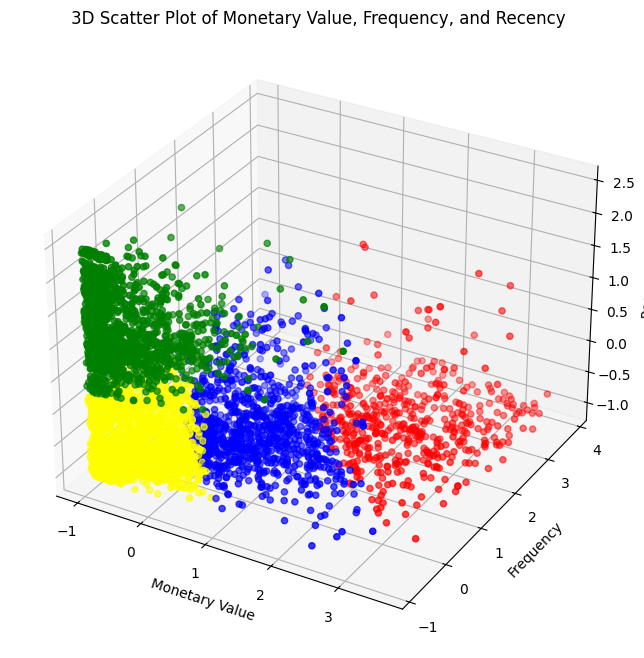

In [57]:
cluster_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'yellow'
}

colors = non_outlier_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(scaled_df['MonetaryValue'], scaled_df['Frequency'], scaled_df['Recency'], c=colors, marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Monetary Value, Frequency, and Recency')

plt.show()

In [58]:
import plotly.graph_objects as go

# Assuming 'non_outlier_df' has a 'Cluster' column with cluster assignments
fig = go.Figure(data=[go.Scatter3d(
    x=non_outlier_df['MonetaryValue'],
    y=non_outlier_df['Frequency'],
    z=non_outlier_df['Recency'],
    mode='markers',
    marker=dict(
        color=non_outlier_df['Cluster'],  # Use cluster assignments for color
        size=5,
        symbol='circle',
        colorscale='Viridis'  # You can choose any colorscale you like
    )
)])

# Update layout (rest is the same as before)
fig.update_layout(
    title='3D Scatter Plot of Monetary Value, Frequency, and Recency',
    scene=dict(
        xaxis_title='Monetary Value',
        yaxis_title='Frequency',
        zaxis_title='Recency'
    ),
    width=800,
    height=800
)

fig.show()

Analysis on various distribution, using violin plot

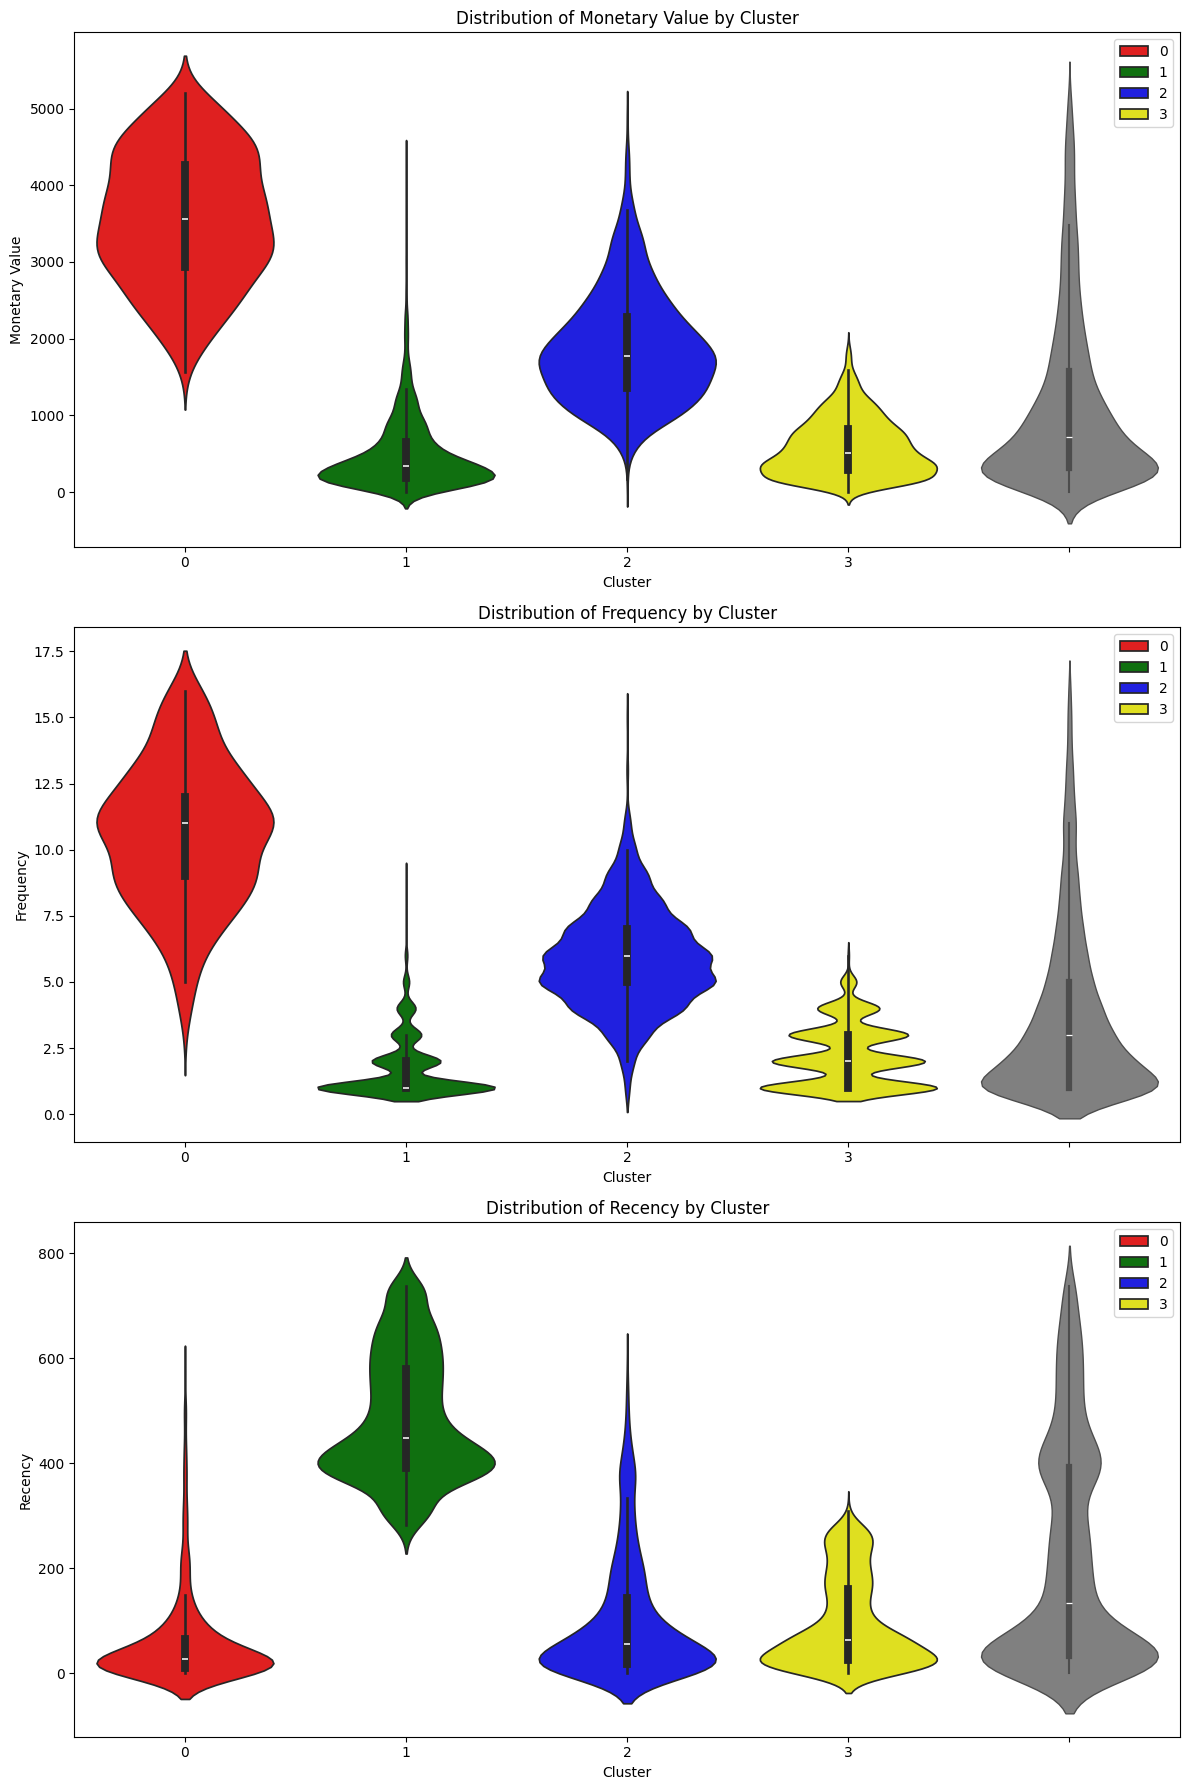

In [59]:
plt.figure(figsize=(12,18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outlier_df['Cluster'], y=non_outlier_df['MonetaryValue'], palette=cluster_colors, hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.ylabel('Monetary Value')
plt.title('Distribution of Monetary Value by Cluster')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outlier_df['Cluster'], y=non_outlier_df['Frequency'], palette=cluster_colors, hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Frequency'], color='gray', linewidth=1.0)
plt.ylabel('Frequency')
plt.title('Distribution of Frequency by Cluster')

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outlier_df['Cluster'], y=non_outlier_df['Recency'], palette=cluster_colors, hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Recency'], color='gray', linewidth=1.0)
plt.ylabel('Recency')
plt.title('Distribution of Recency by Cluster')

plt.tight_layout()
plt.show()

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assuming 'non_outlier_df' and 'cluster_colors' are defined as in your previous code

fig = make_subplots(rows=3, cols=1, subplot_titles=("Distribution of Monetary Value by Cluster",
                                                    "Distribution of Frequency by Cluster",
                                                    "Distribution of Recency by Cluster"))

# Monetary Value Violin Plot
for cluster, color in cluster_colors.items():
    fig.add_trace(go.Violin(x=non_outlier_df['Cluster'][non_outlier_df['Cluster'] == cluster],
                            y=non_outlier_df['MonetaryValue'][non_outlier_df['Cluster'] == cluster],
                            name=f'Cluster {cluster}', line_color=color), row=1, col=1)

fig.add_trace(go.Violin(y=non_outlier_df['MonetaryValue'], line_color='gray', name='Overall', showlegend=False), row=1, col=1)

# Frequency Violin Plot
for cluster, color in cluster_colors.items():
    fig.add_trace(go.Violin(x=non_outlier_df['Cluster'][non_outlier_df['Cluster'] == cluster],
                            y=non_outlier_df['Frequency'][non_outlier_df['Cluster'] == cluster],
                            name=f'Cluster {cluster}', line_color=color, showlegend=False), row=2, col=1)

fig.add_trace(go.Violin(y=non_outlier_df['Frequency'], line_color='gray', name='Overall', showlegend=False), row=2, col=1)

# Recency Violin Plot
for cluster, color in cluster_colors.items():
    fig.add_trace(go.Violin(x=non_outlier_df['Cluster'][non_outlier_df['Cluster'] == cluster],
                            y=non_outlier_df['Recency'][non_outlier_df['Cluster'] == cluster],
                            name=f'Cluster {cluster}', line_color=color, showlegend=False), row=3, col=1)

fig.add_trace(go.Violin(y=non_outlier_df['Recency'], line_color='gray', name='Overall', showlegend=False), row=3, col=1)

# Update layout
fig.update_layout(height=900, width=800, violingap=0, violingroupgap=0, violinmode='overlay')
fig.show()

1. Cluster 0 (Blue) "Retain"


*   Rationale: These are high-value customers with moderate frequency. They haven't purchased very recently and are at risk of becoming inactive. We need to prioritize retaining these customers by reactivating their engagement and strengthening their loyalty.

*   Action: Implement loyalty programs, personalized offers, exclusive access to new products, and proactive customer service to ensure they remain engaged and satisfied. Consider offering premium services or experiences to further enhance their loyalty.


2. Cluster 1 (Green) "Re-Engage"


*   Rationale: This group includes lower-value, infrequent buyers who haven't purchased recently. They have the lowest monetary value and frequency among all clusters. The focus should be on re-engaging them to bring them back into active purchasing behavior.

*   Action: Use targeted marketing campaigns, personalized recommendations, special discounts, or reminders to encourage them to return and purchase again. Consider offering incentives for their next purchase or introducing them to new products that might interest them.






3. Cluster 2 (Red): Reward"


*   Rationale: These are your best customers! They have high monetary value, high frequency, and low recency. They are your most valuable segment and deserve to be rewarded for their loyalty.

*   Action: Offer bundled deals, volume discounts, or loyalty points to incentivize larger purchases. Consider introducing them to higher-value products or services that align with their interests.

4. Cluster 3 (yellow) "Nuture"


*   Rationale: These are frequent buyers with relatively lower monetary value. They purchase often but spend less per transaction. We need to nurture these customers by encouraging them to increase their average transaction value and potentially converting them into higher-value customers.

*   Action: Focus on upselling and cross-selling, implement loyalty programs with tiered rewards, offer exclusive promotions, provide free shipping or perks, and educate them about higher-value products.

In [64]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequncey_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequncey_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers['Cluster'] = -1
frequncey_only_outliers['Cluster'] = -2
monetary_and_frequncey_outliers['Cluster'] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequncey_only_outliers, monetary_and_frequncey_outliers])

outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,77352.96,3,2011-01-18 10:01:00,325,-1
1,12347.00,5633.32,8,2011-12-07 15:52:00,1,-1
10,12356.00,5613.68,6,2011-11-17 08:40:00,22,-1
11,12357.00,17437.66,2,2011-11-06 16:07:00,32,-1
13,12359.00,8935.94,10,2011-10-13 12:47:00,57,-1
...,...,...,...,...,...,...
5790,18226.00,11878.88,26,2011-10-26 13:36:00,43,-3
5793,18229.00,10803.71,28,2011-11-28 09:48:00,11,-3
5795,18231.00,6875.07,28,2011-05-31 14:18:00,191,-3
5809,18245.00,6324.98,20,2011-12-02 14:48:00,6,-3


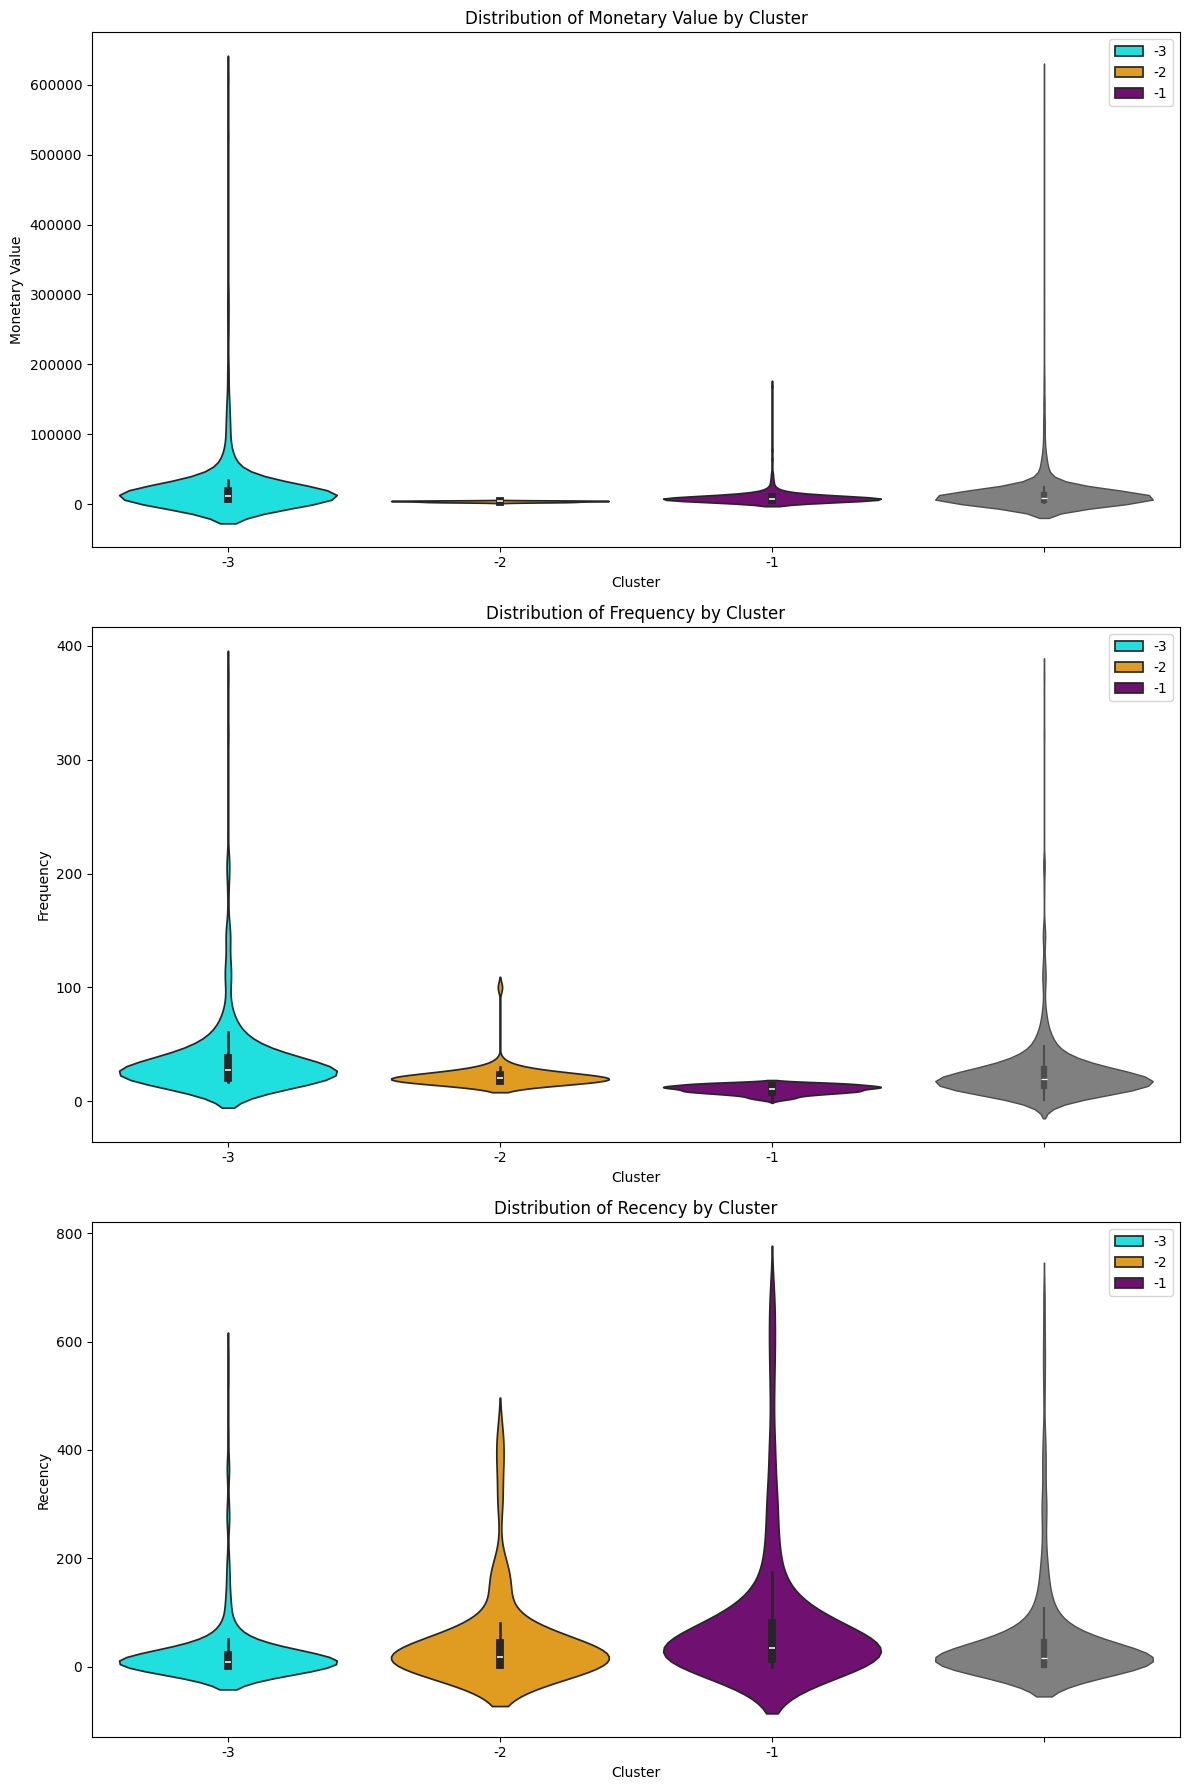

In [66]:
cluster_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'yellow',
    -1: 'purple', # Added color for outlier cluster -1
    -2: 'orange', # Added color for outlier cluster -2
    -3: 'cyan'    # Added color for outlier cluster -3
}

plt.figure(figsize=(12,18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.ylabel('Monetary Value')
plt.title('Distribution of Monetary Value by Cluster')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.ylabel('Frequency')
plt.title('Distribution of Frequency by Cluster')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.ylabel('Recency')
plt.title('Distribution of Recency by Cluster')

plt.tight_layout()
plt.show()

1. Cluster -3 (Monetary and Frequecnt outliers): "Superstars" (Pamper)

* Rationale: This cluster represents extremely high-value customers with exceptional frequency and relatively low recency. They are the most valuable segment and should be treated with utmost care and attention.

* Action: Pamper these customers with exclusive benefits, personalized services, and premium rewards. Consider offering concierge services, early access to new products, and invitations to exclusive events. Maintain consistent communication and build strong relationships to ensure their loyalty.


2. Cluster -2 (Frequency Outliers): "Loyalists" (Reward)

* Rationale: This group comprises frequent buyers with high monetary value and moderate recency. They are loyal customers who consistently generate significant revenue.

* Action: Reward these customers with loyalty programs, tiered benefits, and exclusive discounts. Consider offering personalized recommendations, early access to sales, and birthday rewards to strengthen their loyalty further.

3. Cluster -1 (Monetary outliers): "Big Spenders" (Upsell)

* Rationale: These are customers with high monetary value but lower frequency and higher recency. They tend to make large purchases but less often.

* Action: Focus on upselling and cross-selling opportunities to increase their purchase frequency. Offer personalized recommendations for complementary products, bundled deals, and exclusive promotions. Consider introducing them to higher-value products or services that align with their interests.

In [67]:
 cluster_labels ={
     0: 'Retain',
     1: 'Re-Engage',
     2: 'Reward',
     3: 'Nuture',
     -1: 'Superstars',
     -2: 'Loyalists',
     -3: 'Big Spenders'
 }

In [71]:
full_clustering_df = pd.concat([non_outlier_df, outlier_clusters_df])

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
2,12348.00,1658.40,5,2011-09-25 13:13:00,74,2
3,12349.00,3678.69,3,2011-11-21 09:51:00,18,2
4,12350.00,294.40,1,2011-02-02 16:01:00,309,1
5,12351.00,300.93,1,2010-11-29 15:23:00,374,1
6,12352.00,1729.54,9,2011-11-03 14:37:00,35,2
...,...,...,...,...,...,...
5790,18226.00,11878.88,26,2011-10-26 13:36:00,43,-3
5793,18229.00,10803.71,28,2011-11-28 09:48:00,11,-3
5795,18231.00,6875.07,28,2011-05-31 14:18:00,191,-3
5809,18245.00,6324.98,20,2011-12-02 14:48:00,6,-3


In [72]:
full_clustering_df['Clusterlabels'] = full_clustering_df['Cluster'].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,Clusterlabels
2,12348.00,1658.40,5,2011-09-25 13:13:00,74,2,Reward
3,12349.00,3678.69,3,2011-11-21 09:51:00,18,2,Reward
4,12350.00,294.40,1,2011-02-02 16:01:00,309,1,Re-Engage
5,12351.00,300.93,1,2010-11-29 15:23:00,374,1,Re-Engage
6,12352.00,1729.54,9,2011-11-03 14:37:00,35,2,Reward
...,...,...,...,...,...,...,...
5790,18226.00,11878.88,26,2011-10-26 13:36:00,43,-3,Big Spenders
5793,18229.00,10803.71,28,2011-11-28 09:48:00,11,-3,Big Spenders
5795,18231.00,6875.07,28,2011-05-31 14:18:00,191,-3,Big Spenders
5809,18245.00,6324.98,20,2011-12-02 14:48:00,6,-3,Big Spenders


<ipython-input-75-4d36e1c3983d>:16: UserWarning:


The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.



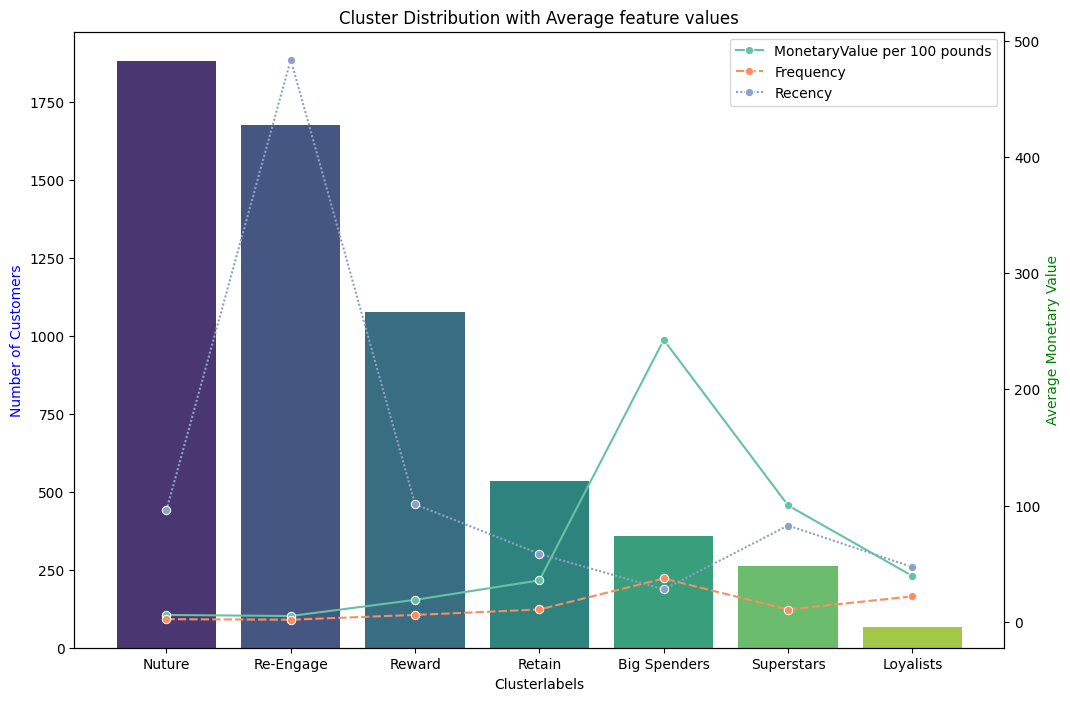

In [75]:
 # visualize all
cluster_count = full_clustering_df['Clusterlabels'].value_counts()
full_clustering_df['MonetaryValue per 100 pounds'] = full_clustering_df['MonetaryValue'] / 100.00
feature_means = full_clustering_df.groupby('Clusterlabels')[['MonetaryValue per 100 pounds', 'Frequency', 'Recency']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

 # Bar plot for cluster counts
sns.barplot(x=cluster_count.index, y=cluster_count.values, ax=ax1, palette='viridis', hue=cluster_count.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title("Cluster Distribution with Average feature values")

ax2 = ax1.twinx()

 # Bar plot for average feature values
sns.lineplot(data=feature_means, palette='Set2', markers='o')
ax2.set_ylabel('Average Monetary Value', color='green')


plt.show()